# Regresión Logística Binaria — Predicción de Reclamaciones de Seguro Automotriz

En este cuadernillo se entrena y valida un modelo de **regresión logística binaria** usando el dataset `DATOS02..csv`, que corresponde a datos de titulares de pólizas de seguro de auto.

**Variable dependiente (`y`):** `target` — indica si el titular presentó una reclamación (`1`) o no (`0`).  
**Variables independientes (`X`):** características de la póliza (indicadores `_ind`, variables de registro `_reg`, del vehículo `_car` y calculadas `_calc`).

In [46]:
# se utiliza para el manejo de rutas y directorios.
import os

# Manipulación y preprocesamiento de datos
import pandas as pd

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

In [45]:
# Ruta local del dataset
RUTA_DATASET = 'DATOS02..csv'

In [47]:
# Cargar datos con Pandas
data_path = os.path.join(os.getcwd(), RUTA_DATASET)
df = pd.read_csv(data_path, sep=';', low_memory=False)

target_col = 'target'
feature_cols = [col for col in df.columns if col not in [target_col, 'id']]

# Convertir a numérico (valores no parseables quedan como NaN y se rellenan con la mediana)
X_df = df[feature_cols].apply(pd.to_numeric, errors='coerce')
X_df = X_df.fillna(X_df.median(numeric_only=True))

X = X_df.values
y = df[target_col].astype(float).values
m = y.size
n = X.shape[1]

# Dos características para graficar puntos (primeras dos variables independientes)
columnas_plot = X_df.columns[:2]
X_plot = X_df[columnas_plot].values

print(f'm = {m}, n = {n}')
print(f'Variable dependiente (y): {target_col}')
print(f'Primeras variables independientes (X): {feature_cols[:5]}')
print('Distribución de clases (target - 1: reclamó, 0: no reclamó):')
print(df[target_col].value_counts())

m = 50000, n = 57
Variable dependiente (y): target
Primeras variables independientes (X): ['ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03', 'ps_ind_04_cat', 'ps_ind_05_cat']
Distribución de clases (target - 1: reclamó, 0: no reclamó):
target
0    48167
1     1833
Name: count, dtype: int64


## Preprocesamiento con Pandas

Se carga el dataset de pólizas de seguro automotriz. La columna `id` se excluye por ser solo un identificador (no aporta información predictiva). La columna `target` es la **variable dependiente `y`** (1 = reclamó, 0 = no reclamó). El resto de columnas son las **variables independientes `X`**.

Los valores no numéricos se convierten con `errors='coerce'` y los nulos resultantes se rellenan con la mediana de cada columna.

In [48]:
def plotData(X, y):
    # Gragica los puntos de datos X y y en una nueva figura. Grafica los puntos de datos con * para los positivos y
    # o para los negativos.

    # Crea una nueva figura
    fig = pyplot.figure()

    # Find Indices of Positive and Negative Examples
    pos = y == 1
    neg = y == 0

    # Plot Examples
    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)


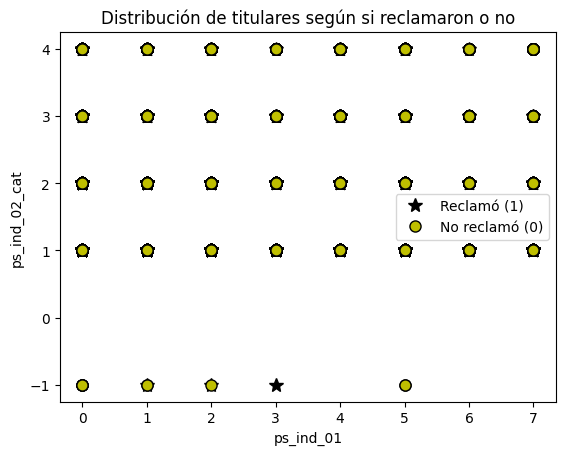

In [49]:
plotData(X_plot, y)
# adiciona etiquetas para los ejes
pyplot.xlabel(f'{columnas_plot[0]}')
pyplot.ylabel(f'{columnas_plot[1]}')
pyplot.title('Distribución de titulares según si reclamaron o no')
pyplot.legend(['Reclamó (1)', 'No reclamó (0)'])
pass

In [50]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

In [51]:
# Prueba la implementacion de la funcion sigmoid
z = [-100, 0.5, 1000000]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [-100, 0.5, 1000000] ) =  [3.72007598e-44 6.22459331e-01 1.00000000e+00]


In [52]:
# Partición 80% entrenamiento y 20% prueba
m_total = X.shape[0]
indices = np.random.permutation(m_total)
tam_train = int(0.8 * m_total)

idx_train = indices[:tam_train]
idx_test = indices[tam_train:]

X_train_raw = X[idx_train]
X_test_raw = X[idx_test]
y_train = y[idx_train]
y_test = y[idx_test]

# Normalización con estadísticas del conjunto de entrenamiento
mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)
sigma[sigma == 0] = 1

X_train_norm = (X_train_raw - mu) / sigma
X_test_norm = (X_test_raw - mu) / sigma

# Configurar matrices agregando la columna de unos (intercepción)
m, n = X_train_norm.shape
X_train = np.concatenate([np.ones((m, 1)), X_train_norm], axis=1)
X_test = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

# Se mantiene el uso de X, y para entrenamiento como en el cuadernillo original
X = X_train
y = y_train

print('Tamaño entrenamiento:', X_train.shape, y_train.shape)
print('Tamaño prueba:', X_test.shape, y_test.shape)

Tamaño entrenamiento: (40000, 58) (40000,)
Tamaño prueba: (10000, 58) (10000,)


## División de datos y normalización

Se divide el dataset en entrenamiento (80%) y prueba (20%).
La normalización se calcula **solo con entrenamiento** para evitar fuga de información hacia prueba.

In [53]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [54]:
def descensoGradiente(theta, X, y, alpha, num_iters, X_val=None, y_val=None):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []
    J_val_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
        if X_val is not None and y_val is not None:
            J_val_history.append(calcularCosto(theta, X_val, y_val))

    return theta, J_history, J_val_history

theta calculado por el descenso por el gradiente:
[-2.81785144e+00  2.07757366e-02 -6.41962720e-03 -3.69475870e-04
  2.27832013e-02  8.28939159e-02 -3.17839830e-02  3.05216671e-02
  3.39859960e-02 -2.66573038e-02 -6.34083949e-04 -1.22711429e-02
  1.44130763e-02 -1.00670132e-02  4.61966200e-03 -4.63134804e-02
 -1.85204038e-02  5.61167810e-02 -6.23082842e-03  2.86263649e-02
  5.54920688e-02  4.06300253e-02 -3.23048723e-03 -3.81919637e-02
  2.74196773e-02  3.87446420e-02  1.70455676e-02  2.13675585e-03
 -3.70918894e-02 -1.52380758e-02 -7.89440627e-03  1.01326267e-02
 -2.20542235e-02 -4.89807380e-03  4.37029963e-02  4.78775738e-02
  1.00670001e-02  2.49635213e-02  2.11169312e-02 -3.67538570e-03
  1.32595769e-02  1.88654406e-02 -1.25297614e-02 -4.66050355e-03
  1.43354812e-02  1.22461367e-02 -2.45729155e-02  1.41904069e-02
  3.30914664e-03  2.12222036e-02  1.02221354e-02  3.11161984e-03
  1.48077706e-02 -2.08676322e-03  2.48152931e-03 -4.21620343e-03
 -1.04905252e-02 -1.06065197e-02]
Probab

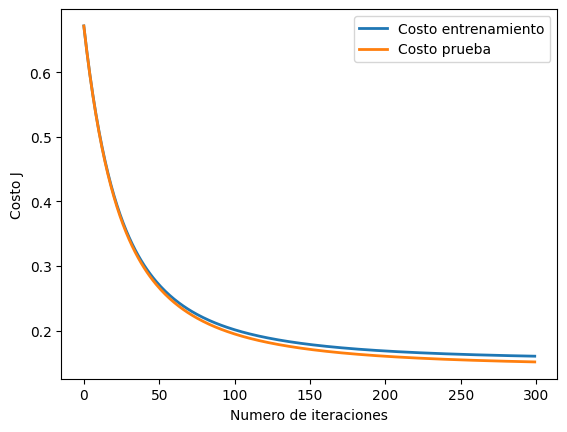

In [55]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.1
num_iters = 300

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(n + 1)
theta, J_history, J_val_history = descensoGradiente(theta, X_train, y_train, alpha, num_iters, X_test, y_test)

# Grafica la convergencia del costo (entrenamiento y prueba)
pyplot.figure()
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, label='Costo entrenamiento')
pyplot.plot(np.arange(len(J_val_history)), J_val_history, lw=2, label='Costo prueba')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.legend()

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente:')
print(theta)

# Predicción sobre un ejemplo real del conjunto de prueba
X_array = X_test[0]
aprueba = sigmoid(np.dot(X_array, theta))

print('Probabilidad predicha para el primer ejemplo de prueba: {:.4f}'.format(aprueba))
print('Etiqueta real del primer ejemplo de prueba:', int(y_test[0]))

In [56]:
# Segunda predicción usando otro ejemplo de prueba
X_array = X_test[1]
y_predicted = sigmoid(np.dot(X_array, theta))
print('Probabilidad predicha para el segundo ejemplo de prueba: {:.4f}'.format(y_predicted))
print('Etiqueta real del segundo ejemplo de prueba:', int(y_test[1]))

Probabilidad predicha para el segundo ejemplo de prueba: 0.0390
Etiqueta real del segundo ejemplo de prueba: 0


In [57]:
def costFunction(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad

In [58]:
# Inicializacion de parametros de ajuste
initial_theta = np.zeros(n + 1)
print('Cantidad de parámetros theta:', initial_theta.size)
cost, grad = costFunction(initial_theta, X, y)

print('Costo en theta inicial (zeros): {:.6f}'.format(cost))
print('Primeros 10 valores del gradiente:')
print(grad[:10])

Cantidad de parámetros theta: 58
Costo en theta inicial (zeros): 0.693147
Primeros 10 valores del gradiente:
[ 0.4626     -0.00446857  0.00057071 -0.00071773 -0.00283445 -0.0068013
  0.00703285 -0.0064177  -0.00413314  0.00229488]


In [59]:
# Calcula y muestra el costo y el gradiente con valores de theta diferentes a cero
test_theta = np.linspace(-0.5, 0.5, n + 1)
print('Primeros 10 parámetros de prueba:')
print(test_theta[:10])
cost, grad = costFunction(test_theta, X, y)

print('Costo en theta prueba: {:.6f}'.format(cost))
print('Primeros 10 valores del gradiente en theta prueba:')
print(grad[:10])

Primeros 10 parámetros de prueba:
[-0.5        -0.48245614 -0.46491228 -0.44736842 -0.42982456 -0.4122807
 -0.39473684 -0.37719298 -0.35964912 -0.34210526]
Costo en theta prueba: 0.893434
Primeros 10 valores del gradiente en theta prueba:
[ 0.39761399 -0.10508251 -0.06793768 -0.08181929 -0.08306156 -0.0671069
  0.06380717 -0.01643997 -0.02834592 -0.03466388]


In [60]:
# Establecer las opciones para optimize.minimize
options = {'maxfun': 1000}

# La función devuelve un objeto `OptimizeResult`
res = optimize.minimize(costFunction,
                        initial_theta,
                        (X, y),
                        jac=True,
                        method='TNC',
                        options=options)

# Resultados optimizados
cost = res.fun
theta = res.x

print('Costo con un valor de theta encontrado por optimize.minimize: {:.6f}'.format(cost))
print('Cantidad de parámetros optimizados:', theta.size)
print('Primeros 10 valores de theta:')
print(theta[:10])

Costo con un valor de theta encontrado por optimize.minimize: 0.154904
Cantidad de parámetros optimizados: 58
Primeros 10 valores de theta:
[-3.36223083e+00  2.57481356e-02 -1.53890966e-02 -1.09443838e-03
  5.02419173e-02  1.54211886e-01 -5.33227828e-02  4.65634759e-02
  6.72556272e-02 -5.30096569e-02]


In [61]:
def plotDecisionBoundary(plotData, theta, X, y):
    """
    Grafica los puntos X e y y, cuando es posible, la frontera de decisión para 2 características.
    """
    # hacer que theta sea un arreglo numpy
    theta = np.array(theta)

    # Graficar los datos (recordar que la primera columna en X es la intercepción)
    plotData(X[:, 1:3], y)

    if X.shape[1] <= 3:
        # Solo se requieren 2 puntos para definir una línea
        plot_x = np.array([np.min(X[:, 1]) - 2, np.max(X[:, 1]) + 2])

        # Calcular la línea límite de decisión
        plot_y = (-1. / theta[2]) * (theta[1] * plot_x + theta[0])

        # Graficar y ajustar los ejes para una mejor visualización
        pyplot.plot(plot_x, plot_y)

        # Leyenda
        pyplot.legend(['Clase 1', 'Clase 0', 'Límite de decisión'])
    else:
        # Para más de 2 características, se mantiene la gráfica de puntos en 2D
        pyplot.title('Visualización en 2D con las dos primeras características')
        pyplot.legend(['Clase 1', 'Clase 0'])

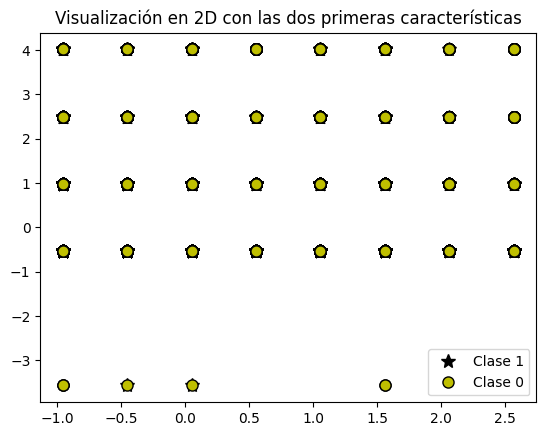

In [62]:
# Graficar limites
plotDecisionBoundary(plotData, theta, X, y)

In [ ]:
def predict(theta, X):

    m = X.shape[0] # Numero de ejemplo de entrenamiento

    p = np.zeros(m)

    p = np.round(sigmoid(X.dot(theta.T)))
    return p

In [64]:
# Predicciones probabilísticas sobre el conjunto de prueba
prob_test = sigmoid(np.dot(X_test[2], theta))
print('Probabilidad de que el titular del seguro presente una reclamación: {:.4f} ({:.2f}%)'.format(prob_test, prob_test * 100))
print('Etiqueta real del ejemplo (1=reclamó, 0=no reclamó):', int(y_test[2]))

# Precisión en entrenamiento y prueba con umbral clásico 0.5
p_train_05 = predict(theta, X_train)
p_test_05 = predict(theta, X_test)
acc_train = np.mean(p_train_05 == y_train) * 100
acc_test_05 = np.mean(p_test_05 == y_test) * 100
print('Precisión de entrenamiento (umbral 0.5): {:.2f} %'.format(acc_train))
print('Precisión de prueba (umbral 0.5): {:.2f} %'.format(acc_test_05))

# Búsqueda de umbral simple para mejorar recuperación de clase positiva
prob_train = sigmoid(X_train.dot(theta.T))
thresholds = np.arange(0.05, 0.51, 0.05)
mejor_threshold = 0.5
mejor_f1 = -1

for t in thresholds:
    p_tmp = (prob_train >= t).astype(int)
    tp_t = np.sum((p_tmp == 1) & (y_train == 1))
    fp_t = np.sum((p_tmp == 1) & (y_train == 0))
    fn_t = np.sum((p_tmp == 0) & (y_train == 1))
    precision_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0.0
    recall_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0
    f1_t = (2 * precision_t * recall_t) / (precision_t + recall_t) if (precision_t + recall_t) > 0 else 0.0
    if f1_t > mejor_f1:
        mejor_f1 = f1_t
        mejor_threshold = t

# Métricas finales en prueba usando el umbral seleccionado
prob_test_full = sigmoid(X_test.dot(theta.T))
p_test_gd = (prob_test_full >= mejor_threshold).astype(int)
acc_test_gd = np.mean(p_test_gd == y_test) * 100

tp = np.sum((p_test_gd == 1) & (y_test == 1))
tn = np.sum((p_test_gd == 0) & (y_test == 0))
fp = np.sum((p_test_gd == 1) & (y_test == 0))
fn = np.sum((p_test_gd == 0) & (y_test == 1))

precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

print('Umbral seleccionado (según entrenamiento):', round(float(mejor_threshold), 2))
print('Precisión de prueba (umbral ajustado): {:.2f} %'.format(acc_test_gd))
print('Matriz de confusión (prueba):')
print('TP:', int(tp), 'FP:', int(fp))
print('FN:', int(fn), 'TN:', int(tn))
print('Precision:', round(float(precision), 4))
print('Recall:', round(float(recall), 4))
print('F1-score:', round(float(f1), 4))

Probabilidad de que el titular del seguro presente una reclamación: 0.0436 (4.36%)
Etiqueta real del ejemplo (1=reclamó, 0=no reclamó): 0
Precisión de entrenamiento (umbral 0.5): 96.26 %
Precisión de prueba (umbral 0.5): 96.63 %
Umbral seleccionado (según entrenamiento): 0.05
Precisión de prueba (umbral ajustado): 79.62 %
Matriz de confusión (prueba):
TP: 96 FP: 1797
FN: 241 TN: 7866
Precision: 0.0507
Recall: 0.2849
F1-score: 0.0861


## Validación del modelo

Se reporta desempeño en entrenamiento y en prueba, junto con matriz de confusión, precisión y recall para verificar la efectividad del clasificador.